<a href="https://colab.research.google.com/github/huyle2411-hub/credit-risk-scorecard/blob/main/main/03_scorecard_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Scorecard — Notebook 03: Scorecard Evaluation

**Mục tiêu notebook này:** Huấn luyện logistic scorecard trên biến đã WOE-hóa, đánh giá (AUC/KS/Gini/calibration), quy đổi thang điểm, kiểm PSI.

In [1]:
!pip install optbinning -q
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from optbinning import BinningProcess
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.calibration import calibration_curve
import statsmodels.api as sm
pd.set_option('display.max_columns', None)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.8/214.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.1/28.1 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 18.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 5.26.1 which is incompatible.
grain 0.2.18 requires protobuf>=5.28.3, but you have protobuf 5.26.1 which is incompatible.
tensorflow 2.20.0 requires protobuf>=5.28.0, but you have protobuf 5.26.1 which is incompatible.


##1. Nạp và chạy lại pipeline làm sạch của Notebook 02
Lặp lại cleaning + WOE + chọn biến IV>=0.02.

In [3]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('cs-training.csv', index_col=0)
target = 'SeriousDlqin2yrs'
late = ['NumberOfTime30-59DaysPastDueNotWorse','NumberOfTimes90DaysLate','NumberOfTime60-89DaysPastDueNotWorse']

# --- lap lai cleaning tu NB02 (de notebook nay tu chay duoc) ---
d = df.copy()
d['severe_delinq_flag'] = (d[late] >= 90).any(axis=1).astype(int)
d[late] = d[late].mask(d[late] >= 90)
d['age'] = d['age'].replace(0, np.nan)
for c in ['RevolvingUtilizationOfUnsecuredLines','DebtRatio']:
    d[c] = d[c].clip(upper=d[c].quantile(0.99))
d['NumberOfDependents'] = d['NumberOfDependents'].fillna(0)

# --- WOE transform + chon bien IV>=0.02 ---
y = d[target].values
X = d.drop(columns=[target])
bp = BinningProcess(variable_names=list(X.columns)); bp.fit(X.values, y)
Xw = pd.DataFrame(bp.transform(X.values), columns=X.columns, index=X.index)
iv = bp.summary().set_index('name')['iv']
keep = [c for c in X.columns if iv[c] >= 0.02]
Xw = Xw[keep]
print('Bien dung cho model (%d):' % len(keep), keep)

Saving cs-training.csv to cs-training.csv
Bien dung cho model (10): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


##2. Train/Test & Stratify

Chia dữ liệu thành train và test để đánh giá khả năng tổng quát hóa của mô hình trên dữ liệu chưa từng thấy. Sử dụng stratify để giữ nguyên tỷ lệ khách hàng vỡ nợ (khoảng 6.7%) ở cả hai tập, vì đây là bài toán mất cân bằng dữ liệu; nếu chia ngẫu nhiên thuần túy, tỷ lệ default có thể lệch đáng kể và làm sai lệch kết quả đánh giá.



In [4]:
Xtr, Xte, ytr, yte = train_test_split(Xw, y, test_size=0.3, stratify=y, random_state=42)
print('train:', Xtr.shape, ' test:', Xte.shape)

train: (105000, 10)  test: (45000, 10)


##3. Logistic Regression

Chọn Logistic Regression làm mô hình chính vì đây là chuẩn mực phổ biến trong scorecard ngân hàng: mô hình minh bạch, hệ số có thể giải thích được, dễ kiểm toán và dễ triển khai chính sách tín dụng. Mục tiêu không chỉ là đạt độ chính xác cao nhất mà còn phải đảm bảo khả năng giải thích và quản trị rủi ro.

In [5]:
logit = sm.Logit(ytr, sm.add_constant(Xtr)).fit(disp=0)
p_tr = logit.predict(sm.add_constant(Xtr))
p_te = logit.predict(sm.add_constant(Xte))
print(logit.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:               105000
Model:                          Logit   Df Residuals:                   104989
Method:                           MLE   Df Model:                           10
Date:                Sun, 05 Jul 2026   Pseudo R-squ.:                  0.2437
Time:                        17:35:19   Log-Likelihood:                -19486.
converged:                       True   LL-Null:                       -25765.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                   -0.8513      0.154     -5.539      0.000      -1.152      -0.550
RevolvingUtilizationOfUnsecuredLines    -0.6344      

##4. AUC, KS, Gini

AUC đo khả năng mô hình xếp khách hàng rủi ro cao lên trên khách hàng rủi ro thấp; AUC càng lớn thì khả năng phân biệt càng tốt. KS là khoảng cách lớn nhất giữa phân phối tích lũy của nhóm tốt và nhóm xấu, phản ánh mức độ tách biệt giữa hai nhóm. Gini là cách biểu diễn khác của AUC với công thức Gini = 2 × AUC − 1; Gini càng cao thì mô hình càng mạnh.

TEST  AUC = 0.8519 | Gini = 0.7037 | KS = 0.5523
TRAIN AUC = 0.8514  (so sanh de kiem overfit)


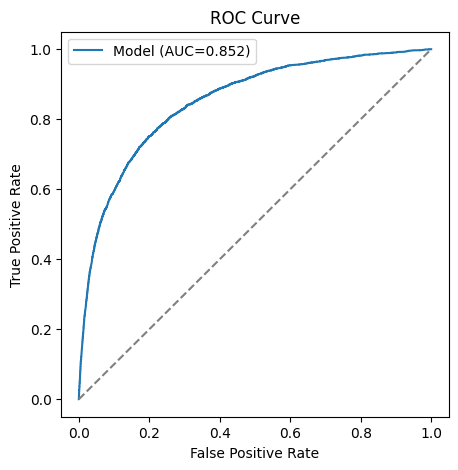

In [6]:
def ks_stat(y_true, prob):
    fpr, tpr, _ = roc_curve(y_true, prob)
    return np.max(tpr - fpr)

auc = roc_auc_score(yte, p_te)
print('TEST  AUC = %.4f | Gini = %.4f | KS = %.4f' % (auc, 2*auc-1, ks_stat(yte, p_te)))
print('TRAIN AUC = %.4f  (so sanh de kiem overfit)' % roc_auc_score(ytr, p_tr))

fpr, tpr, _ = roc_curve(yte, p_te)
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label='Model (AUC=%.3f)' % auc)
plt.plot([0,1],[0,1],'--',color='grey')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve'); plt.legend(); plt.show()

##5. Calibration

Calibration kiểm tra xem xác suất vỡ nợ dự đoán có khớp với tỷ lệ vỡ nợ thực tế hay không. Điều này đặc biệt quan trọng với scorecard vì ngân hàng cần PD (Probability of Default) đúng, không chỉ cần mô hình xếp hạng khách hàng đúng.

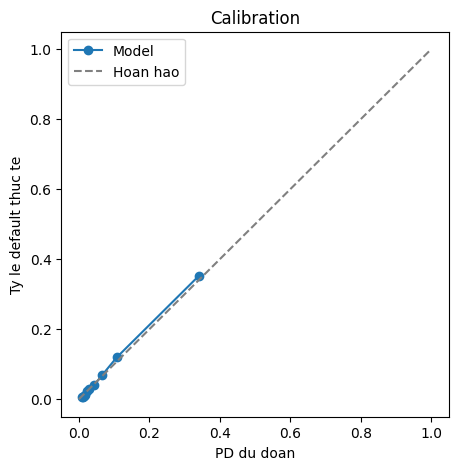

In [7]:
frac_pos, mean_pred = calibration_curve(yte, p_te, n_bins=10, strategy='quantile')
plt.figure(figsize=(5,5))
plt.plot(mean_pred, frac_pos, 'o-', label='Model')
plt.plot([0,1],[0,1],'--',color='grey', label='Hoan hao')
plt.xlabel('PD du doan'); plt.ylabel('Ty le default thuc te')
plt.title('Calibration'); plt.legend(); plt.show()

##6. Quy đổi PD thành điểm (PDO)

Xác suất vỡ nợ được quy đổi thành thang điểm tín dụng theo quy ước PDO = 20, nghĩa là cứ tăng 20 điểm thì odds tốt/xấu tăng gấp đôi. Chọn mốc 600 điểm tại odds 50:1; vì vậy điểm càng cao thì rủi ro càng thấp.

Diem: min 433 | mean 583 | max 635


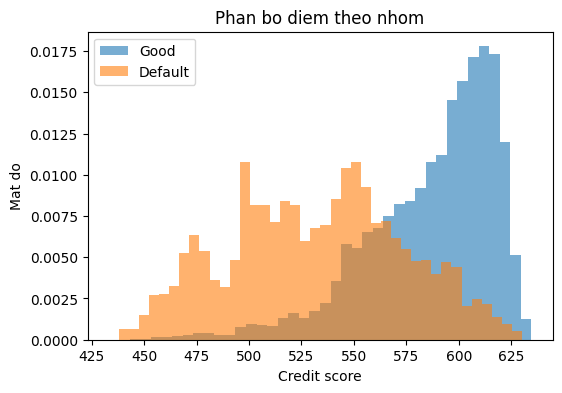

In [8]:
factor = 20 / np.log(2)
offset = 600 - factor * np.log(50)

def to_score(p):
    odds = (1 - p) / np.clip(p, 1e-9, 1)
    return offset + factor * np.log(odds)

score_te = to_score(p_te)
print('Diem: min %.0f | mean %.0f | max %.0f' % (score_te.min(), score_te.mean(), score_te.max()))

plt.figure(figsize=(6,4))
plt.hist(score_te[yte==0], bins=40, alpha=0.6, label='Good', density=True)
plt.hist(score_te[yte==1], bins=40, alpha=0.6, label='Default', density=True)
plt.xlabel('Credit score'); plt.ylabel('Mat do'); plt.title('Phan bo diem theo nhom')
plt.legend(); plt.show()

##7. PSI

PSI (Population Stability Index) đo mức độ dịch chuyển của phân phối điểm giữa hai tập dữ liệu; thông thường PSI dưới 0.1 được xem là ổn định. Tuy nhiên cần lưu ý rằng trong bài này train và test được tách ngẫu nhiên từ cùng một tập dữ liệu, nên PSI gần 0 là điều khá hiển nhiên. Kết quả này không chứng minh mô hình ổn định theo thời gian thực; để đánh giá đúng cần so sánh với dữ liệu của các kỳ sau.

In [9]:
def psi(expected, actual, bins=10):
    q = np.quantile(expected, np.linspace(0,1,bins+1)); q[0]=-np.inf; q[-1]=np.inf
    e = np.clip(np.histogram(expected, q)[0]/len(expected), 1e-6, None)
    a = np.clip(np.histogram(actual, q)[0]/len(actual), 1e-6, None)
    return np.sum((a - e) * np.log(a / e))

print('PSI (train vs test): %.4f' % psi(to_score(p_tr), score_te))

PSI (train vs test): 0.0003


**→** Tóm tắt kết quả [...] và chuyển sang NB04: so sánh với một boosting challenger và viết lại logic scoring bằng SQL (DuckDB).